In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from pathlib import Path
import random

In [ ]:
DATASET_PATH = Path("../dataset/plantvillage dataset/grayscale")

In [ ]:
classes = sorted(os.listdir(DATASET_PATH))

classes = [c for c in classes if not c.startswith('.')]

print(f"📊 Total number of classes: {len(classes)}")
print(f"\n📋 All disease classes:")
for i, cls in enumerate(classes):
    print(f"  {i+1:02d}. {cls}")


📊 Total number of classes: 38

📋 All disease classes:
  01. Apple___Apple_scab
  02. Apple___Black_rot
  03. Apple___Cedar_apple_rust
  04. Apple___healthy
  05. Blueberry___healthy
  06. Cherry_(including_sour)___Powdery_mildew
  07. Cherry_(including_sour)___healthy
  08. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
  09. Corn_(maize)___Common_rust_
  10. Corn_(maize)___Northern_Leaf_Blight
  11. Corn_(maize)___healthy
  12. Grape___Black_rot
  13. Grape___Esca_(Black_Measles)
  14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
  15. Grape___healthy
  16. Orange___Haunglongbing_(Citrus_greening)
  17. Peach___Bacterial_spot
  18. Peach___healthy
  19. Pepper,_bell___Bacterial_spot
  20. Pepper,_bell___healthy
  21. Potato___Early_blight
  22. Potato___Late_blight
  23. Potato___healthy
  24. Raspberry___healthy
  25. Soybean___healthy
  26. Squash___Powdery_mildew
  27. Strawberry___Leaf_scorch
  28. Strawberry___healthy
  29. Tomato___Bacterial_spot
  30. Tomato___Early_blight
  

In [4]:
class_counts = {}

for cls in classes:
    cls_path = DATASET_PATH / cls
    # Fix: count ALL image extensions, both upper and lowercase
    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    class_counts[cls] = len(images)

# Summary statistics
total_images = sum(class_counts.values())
print(f"📸 Total images in dataset: {total_images:,}")
print(f"📊 Average images per class: {total_images // len(classes):,}")
print(f"📈 Largest class:  {max(class_counts, key=class_counts.get)} ({max(class_counts.values()):,} images)")
print(f"📉 Smallest class: {min(class_counts, key=class_counts.get)} ({min(class_counts.values()):,} images)")

📸 Total images in dataset: 54,305
📊 Average images per class: 1,429
📈 Largest class:  Orange___Haunglongbing_(Citrus_greening) (5,507 images)
📉 Smallest class: Potato___healthy (152 images)


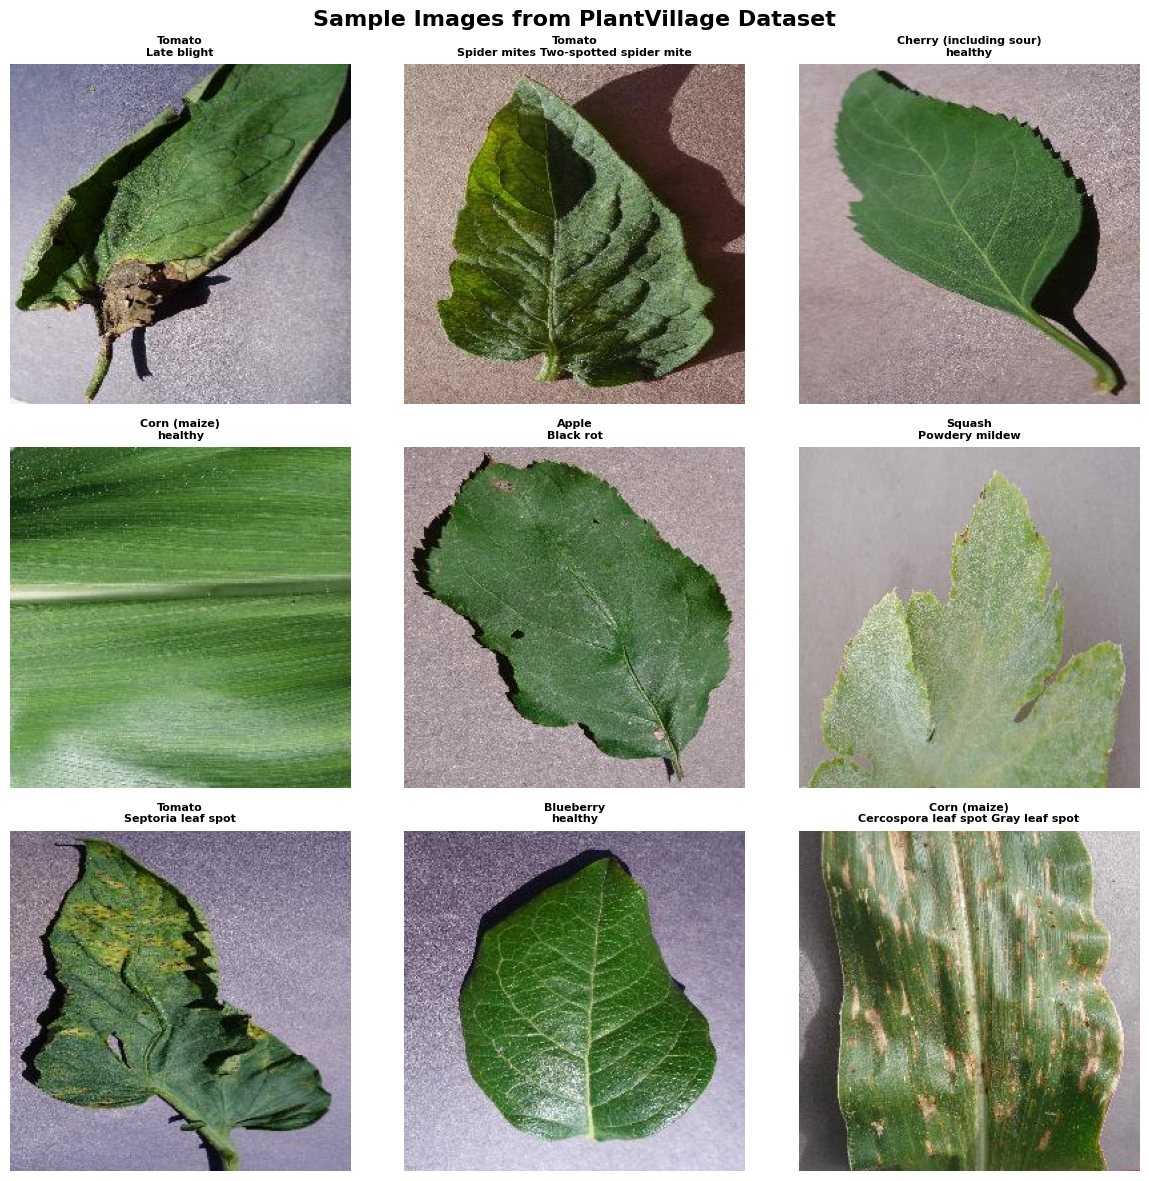

In [5]:
# Pick 9 random classes to display
sample_classes = random.sample(classes, 9)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle('Sample Images from PlantVillage Dataset', 
             fontsize=16, fontweight='bold')

for ax, cls in zip(axes.flatten(), sample_classes):
    cls_path = DATASET_PATH / cls
    # Pick a random image from this class
    images = os.listdir(cls_path)
    img_path = cls_path / random.choice(images)
    
    # Load and display image
    img = mpimg.imread(img_path)
    ax.imshow(img)
    
    # Clean up the class name for display
    clean_name = cls.replace('___', '\n').replace('_', ' ')
    ax.set_title(clean_name, fontsize=8, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('../report/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

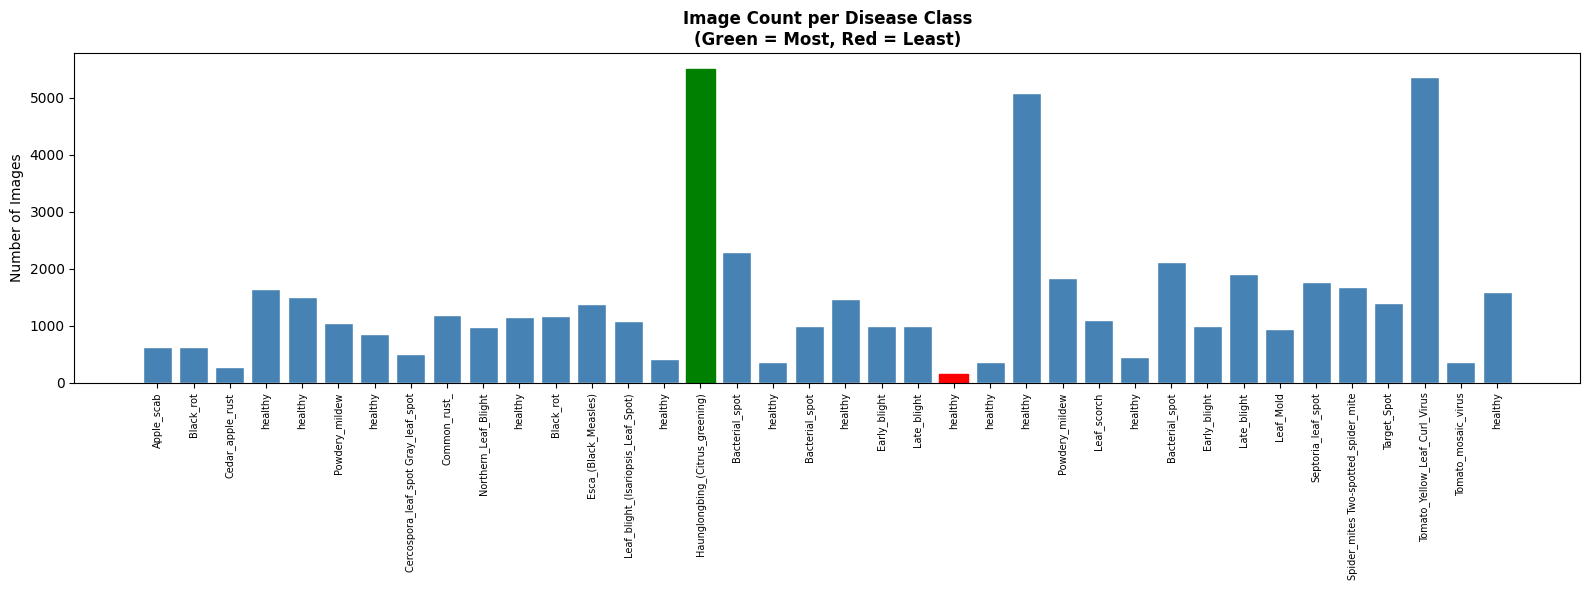

In [6]:
short_names = [c.split('___')[1] if '___' in c else c 
               for c in class_counts.keys()]
counts = list(class_counts.values())

plt.figure(figsize=(16, 6))
bars = plt.bar(range(len(counts)), counts, color='steelblue', edgecolor='white')

# Highlight min and max
max_idx = counts.index(max(counts))
min_idx = counts.index(min(counts))
bars[max_idx].set_color('green')
bars[min_idx].set_color('red')

plt.xticks(range(len(short_names)), short_names, 
           rotation=90, fontsize=7)
plt.ylabel('Number of Images')
plt.title('Image Count per Disease Class\n(Green = Most, Red = Least)', 
          fontweight='bold')
plt.tight_layout()
plt.savefig('../report/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load one sample image
sample_class = "Tomato___Early_blight"
sample_folder = DATASET_PATH / sample_class
sample_image_path = list(sample_folder.iterdir())[0]

# Load image using OpenCV
img_original = cv2.imread(str(sample_image_path))

# OpenCV loads as BGR — convert to RGB for display
img_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

print(f"📐 Original image shape: {img_rgb.shape}")
print(f"📊 Pixel value range: {img_rgb.min()} to {img_rgb.max()}")
print(f"💾 Data type: {img_rgb.dtype}")
print(f"\n💡 Shape means: {img_rgb.shape[0]}px height x "
      f"{img_rgb.shape[1]}px width x "
      f"{img_rgb.shape[2]} color channels (RGB)")

📐 Original image shape: (256, 256, 3)
📊 Pixel value range: 0 to 255
💾 Data type: uint8

💡 Shape means: 256px height x 256px width x 3 color channels (RGB)


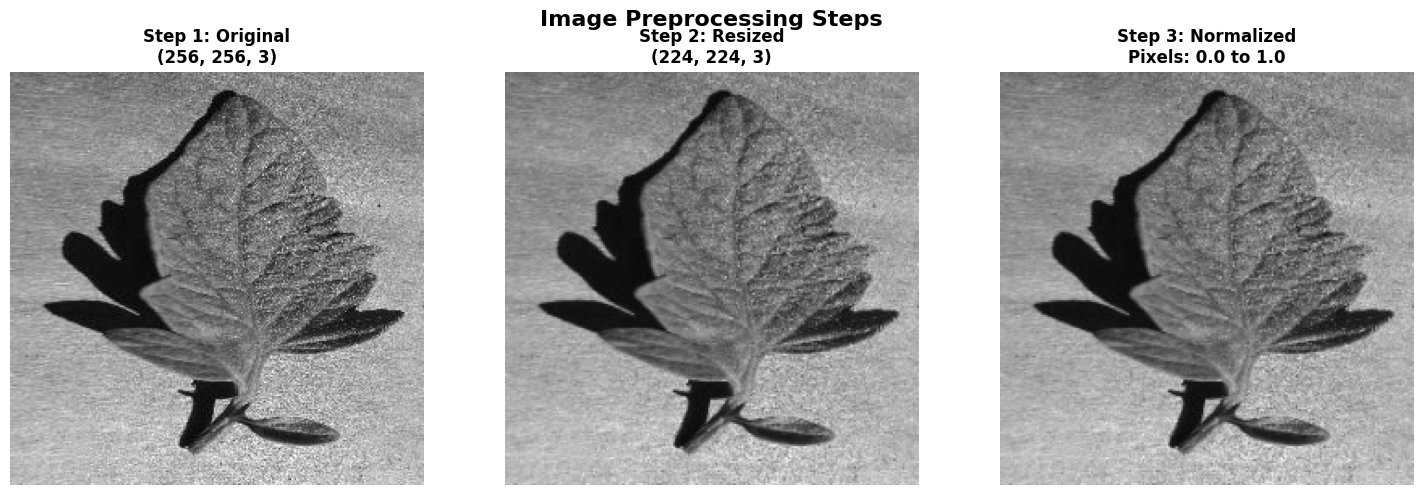

Before normalization - min: 3, max: 250
After normalization  - min: 0.0, max: 1.0


In [ ]:
# ============================================
# Visualize each preprocessing step
# ============================================

# --- Step 1: Original Image ---
img_original = cv2.cvtColor(
    cv2.imread(str(sample_image_path)), 
    cv2.COLOR_BGR2RGB
)

# --- Step 2: Resize to 224x224 ---
# Why 224x224? This is the standard input size for
# most CNN architectures (MobileNet, ResNet, VGG)
IMG_SIZE = 224
img_resized = cv2.resize(img_original, (IMG_SIZE, IMG_SIZE))

# --- Step 3: Normalize pixel values ---
# Why normalize? Raw pixels are 0-255
# Neural networks work better with small values (0-1)
# This helps gradients flow properly during training
img_normalized = img_resized / 255.0

# --- Display all 3 steps side by side ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Image Preprocessing Steps', 
             fontsize=16, fontweight='bold')

axes[0].imshow(img_original)
axes[0].set_title(f'Step 1: Original\n{img_original.shape}', 
                  fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_resized)
axes[1].set_title(f'Step 2: Resized\n{img_resized.shape}', 
                  fontweight='bold')
axes[1].axis('off')

axes[2].imshow(img_normalized)
axes[2].set_title(f'Step 3: Normalized\nPixels: 0.0 to 1.0', 
                  fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('../report/preprocessing_steps.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Before normalization - min: {img_resized.min()}, max: {img_resized.max()}")
print(f"After normalization  - min: {img_normalized.min():.1f}, max: {img_normalized.max():.1f}")

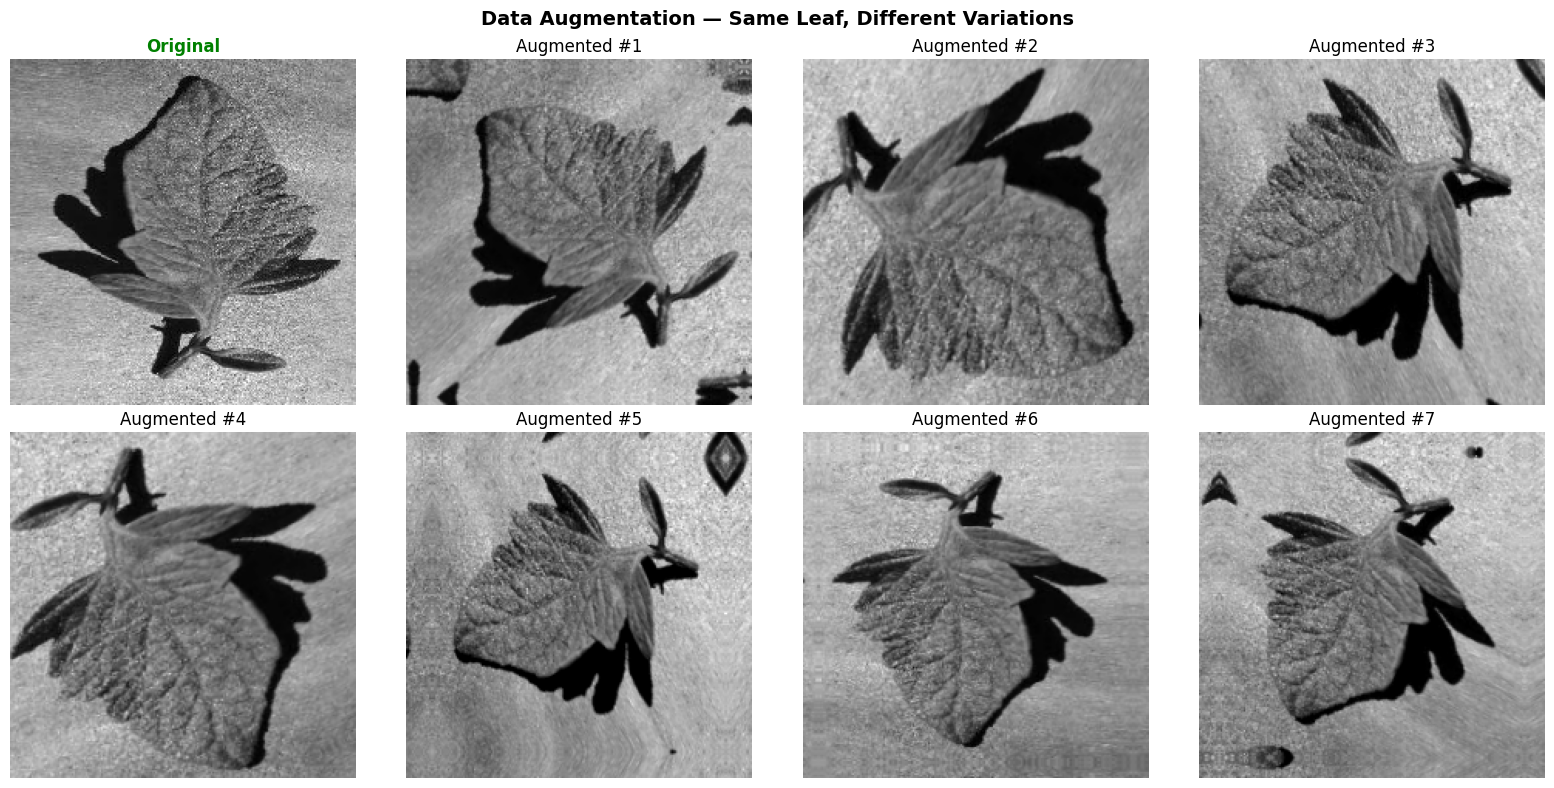

✅ Augmentation working correctly!


In [ ]:
# ============================================
# Data Augmentation
# Why? To artificially increase dataset size
# and make model robust to real-world variations
# A farmer might take photos at different angles,
# lighting conditions, or distances
# ============================================
import tensorflow as tf
import matplotlib.pyplot as plt

# Load image WITHOUT normalizing first
img = tf.keras.preprocessing.image.load_img(
    str(sample_image_path),
    target_size=(224, 224)
)
img_array = tf.keras.preprocessing.image.img_to_array(img)
# Keep pixels as 0-255 for augmentation display

# Define augmentation
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

# Display
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Data Augmentation — Same Leaf, Different Variations',
             fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    if i == 0:
        ax.imshow(img_array.astype('uint8'))
        ax.set_title('Original', fontweight='bold', color='green')
    else:
        augmented = augmentation(
            tf.expand_dims(img_array, 0), training=True
        )
        ax.imshow(tf.squeeze(augmented).numpy().astype('uint8'))
        ax.set_title(f'Augmented #{i}')
    ax.axis('off')

plt.tight_layout()
plt.savefig('../report/augmentation_examples.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Augmentation working correctly!")

In [ ]:
# ============================================
# Production-ready data loader
# This is what we'll use for actual training
# ============================================
import tensorflow as tf
from pathlib import Path

# --- Configuration ---
DATASET_PATH = Path("../dataset/plantvillage dataset/color")
IMG_SIZE     = 224      # Standard CNN input size
BATCH_SIZE   = 32       # Images processed at once
SEED         = 42       # For reproducibility

# --- Load dataset with automatic train/val split ---
# 80% training, 20% validation
print("📂 Loading training data...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,   # 20% for validation
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical' # One-hot encoded labels
)

print("\n📂 Loading validation data...")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# --- Get class names ---
class_names = train_dataset.class_names
print(f"\n✅ Classes loaded: {len(class_names)}")

# --- Count batches ---
train_batches = tf.data.experimental.cardinality(train_dataset).numpy()
val_batches   = tf.data.experimental.cardinality(val_dataset).numpy()
print(f"🏋️  Training batches:   {train_batches} ({train_batches * BATCH_SIZE:,} images approx)")
print(f"✅ Validation batches: {val_batches} ({val_batches * BATCH_SIZE:,} images approx)")

# --- Optimize loading speed ---
# prefetch loads next batch while current is training
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset   = val_dataset.prefetch(buffer_size=AUTOTUNE)

print("\n🎉 Data loader ready for training!")

📂 Loading training data...
Found 54305 files belonging to 38 classes.
Using 43444 files for training.

📂 Loading validation data...
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.

✅ Classes loaded: 38
🏋️  Training batches:   1358 (43,456 images approx)
✅ Validation batches: 340 (10,880 images approx)

🎉 Data loader ready for training!
